### run-and-plot-convergence-sweep

Fast numerical-convergence check for the grid sizes in `config/base/Cu-seed-SASE.yaml`
(tgrid, xgrid=ygrid, zgrid), at E_seed_uJ=40. Unlike `run-transmittance-vs-intensity.ipynb`
and `plot-convergence-sweep.ipynb`, this notebook swaps the stochastic SASE seed
(`Ocelot_SASE_seed_pstxy`, which needs ~10s-100s of repetitions averaged together to beat
down shot noise) for a **deterministic Gaussian seed** (`tools.Gaussian_pulse_aniso_seed`,
same seed energy/duration/width as the SASE base config). A Gaussian seed is
noise-free, so **one run per grid setting is enough** -- there's no repetition loop,
no multiprocessing, and no SLURM array needed; this runs directly in the notebook.

That speed comes at a cost: a Gaussian seed's T(ω) is not the same physical
quantity as a SASE run's ensemble-averaged T(ω) (no shot-to-shot speckle/self-seeding
statistics), so treat this as a grid-resolution sanity check, not a substitute for
the SASE convergence numbers in `plot-convergence-sweep.ipynb` -- use it to catch
gross under-resolution quickly, then confirm the grid choice with a proper SASE
sweep before trusting production results.

### import libraries

In [14]:
import os
import tempfile
from collections import OrderedDict

import yaml
import numpy as np
import matplotlib.pyplot as plt

from XLO_sim.XLO_sim import XLO_sim
from XLO_sim import tools

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

figs_path = os.path.join(base_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

BASE_YAML = os.path.join(base_directory, 'config/base/Cu-seed.yaml')
TPAD = 1000
YPAD = 64

with open(BASE_YAML, 'r') as f:
    base_config = yaml.safe_load(f)
print('base grid: tgrid={tgrid}, xgrid={xgrid}, ygrid={ygrid}, zgrid={zgrid}, E_seed_uJ={E_seed_uJ}'.format(**base_config))


base grid: tgrid=200, xgrid=8, ygrid=8, zgrid=15, E_seed_uJ=40


### grid sweeps

Same three axes and defaults as `scripts/generate_tgrid_sweep_configs.py` /
`generate_xygrid_sweep_configs.py` / `generate_zgrid_sweep_configs.py`: one
axis varies at a time, the other two held at tgrid=800, xgrid=ygrid=8,
zgrid=15.

In [15]:
TGRID_VALUES = [200, 400, 800, 1600, 3200, 6400, 12800, 20000]
XYGRID_VALUES = [2, 4, 8, 16, 32]
ZGRID_VALUES = [5, 10, 15, 20, 30, 40, 50]

FIXED_TGRID = 800
FIXED_XYGRID = 8
FIXED_ZGRID = 15


### run + post-process

`run_gaussian_config` builds an in-memory config (base config, seed switched
to the deterministic Gaussian pulse, grid overridden), writes it to a temp
YAML (XLO_sim reads configs from a file path), runs a single realization,
and returns the T(ω) trace plus the density-matrix time traces used by
`plot-transmittance-vs-intensity.ipynb`. `run_grid_sweep` loops that over one
axis's grid values, holding the other two axes fixed.

In [16]:
def run_gaussian_config(tgrid, xgrid, ygrid, zgrid):
    config = dict(base_config)
    config['tgrid'] = tgrid
    config['xgrid'] = xgrid
    config['ygrid'] = ygrid
    config['zgrid'] = zgrid
    # Deterministic seed instead of the stochastic SASE seed -- no repetitions needed.
    config['seed_pulse_format'] = 'Gaussian_pulse_aniso_seed'

    with tempfile.NamedTemporaryFile(mode='w', suffix='.yaml', delete=False) as f:
        yaml.safe_dump(config, f)
        tmp_path = f.name

    try:
        X = XLO_sim(tmp_path)
        seed_field = tools.Gaussian_pulse_aniso_seed(X)
        X.configure(seed_field)
        X.run_3D()

        womega_ar, I_int_thy_w_0, _ = tools.SF_spectrum_w(X, 0, YPAD, TPAD)
        womega_ar, I_int_thy_w_last, _ = tools.SF_spectrum_w(X, -1, YPAD, TPAD)

        result = {
            'womega_ar': womega_ar,
            'I_int_thy_w_0': I_int_thy_w_0,
            'I_int_thy_w_last': I_int_thy_w_last,
            't_axis': X.t,
            'rho_ee_t_last': np.einsum(
                'ijs, jkt, kis-> t', X.Tijs_minus,
                X.rho_ijtxyz[:, :, :, int(X.xgrid / 2), int(X.ygrid / 2), -1],
                X.Tijs_plus, optimize=True,
            ),
            'rho_gg_t_last': np.einsum(
                'ijs, jkt, kis-> t', X.Tijs_plus,
                X.rho_ijtxyz[:, :, :, int(X.xgrid / 2), int(X.ygrid / 2), -1],
                X.Tijs_minus, optimize=True,
            ),
            'rho_ground_t_last': X.rho_ground_txyz[:, int(X.xgrid / 2), int(X.ygrid / 2), -1],
            'rho_other_t_last': X.rho_other_txyz[:, int(X.xgrid / 2), int(X.ygrid / 2), -1],
            'rho_2s_t_last': X.rho_2s_txyz[:, int(X.xgrid / 2), int(X.ygrid / 2), -1],
        }
    finally:
        os.remove(tmp_path)

    return result


def run_grid_sweep(grid_label, grid_values, fixed_tgrid, fixed_xygrid, fixed_zgrid):
    results = OrderedDict()
    for grid_value in grid_values:
        tgrid = grid_value if grid_label == 'tgrid' else fixed_tgrid
        xgrid = ygrid = grid_value if grid_label == 'xgrid' else fixed_xygrid
        zgrid = grid_value if grid_label == 'zgrid' else fixed_zgrid

        print(f'running {grid_label}={grid_value}  (tgrid={tgrid}, xgrid=ygrid={xgrid}, zgrid={zgrid})', flush=True)
        results[grid_value] = run_gaussian_config(tgrid, xgrid, ygrid, zgrid)

    return results


### plotting

Same T(ω) overlay + min(T)/area/FWHM dip-metrics-vs-grid-value plots as
`plot-convergence-sweep.ipynb`, adapted for a single realization per grid
value (no repetition averaging).

In [17]:
def transmittance_dip_metrics(results, w_mask=15, n_edge=10):
    grid_values, min_T, area_T, FWHM_T = [], [], [], []

    for grid_value, arrays in results.items():
        womega_ar = arrays['womega_ar']
        I_int_thy_w_last = arrays['I_int_thy_w_last'] + 1e-5 * max(arrays['I_int_thy_w_last'])
        I_int_thy_w_0 = arrays['I_int_thy_w_0'] + 1e-5 * max(arrays['I_int_thy_w_0'])
        Tint_w = I_int_thy_w_last / I_int_thy_w_0

        mask = (womega_ar > -w_mask) & (womega_ar < w_mask)

        grid_values.append(grid_value)
        min_T.append(np.min(Tint_w[mask]))

        T_base = 0.5 * (np.mean(Tint_w[mask][:n_edge]) + np.mean(Tint_w[mask][-n_edge:]))
        dip = T_base - Tint_w[mask]
        area_T.append(np.trapz(dip))
        FWHM_T.append(tools.find_fwhm(womega_ar[mask], dip))

    return grid_values, min_T, area_T, FWHM_T


def plot_grid_sweep(results, grid_label, w_show=15):
    grid_values = list(results.keys())
    norm = plt.matplotlib.colors.LogNorm(vmin=min(grid_values), vmax=max(grid_values))
    cmap = plt.matplotlib.colormaps['viridis']

    plt.figure()
    plt.title(f'Gaussian-seed transmittance vs {grid_label} (single shot, E_seed = 40 uJ)', fontsize=9)
    for grid_value, arrays in results.items():
        womega_ar = arrays['womega_ar']
        I_int_thy_w_last = arrays['I_int_thy_w_last'] + 1e-5 * max(arrays['I_int_thy_w_last'])
        I_int_thy_w_0 = arrays['I_int_thy_w_0'] + 1e-5 * max(arrays['I_int_thy_w_0'])
        Tint_w = I_int_thy_w_last / I_int_thy_w_0
        plt.plot(womega_ar, Tint_w, color=cmap(norm(grid_value)), label=f'{grid_label} = {grid_value}')

    plt.ylabel(r'$T(\omega)$')
    plt.xlabel(r'$\Delta\omega$ (eV)')
    plt.xlim(-w_show, w_show)
    plt.legend(fontsize=7)
    plt.grid(True)
    plt.savefig(os.path.join(figs_path, f'gaussian_convergence_{grid_label}_transmittance.pdf'))
    plt.show()

    grid_values, min_T, area_T, FWHM_T = transmittance_dip_metrics(results)

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    for ax, y, ylabel, title in zip(
        axs,
        [min_T, area_T, FWHM_T],
        ['min(T)', 'Area of transmittance dip', 'FWHM of transmittance dip (eV)'],
        ['Minimum transmittance', 'Dip area', 'Dip FWHM'],
    ):
        ax.plot(grid_values, y, marker='o')
        ax.set_xscale('log')
        ax.set_xlabel(grid_label)
        ax.set_ylabel(ylabel)
        ax.set_title(f'{title} vs {grid_label}')
        ax.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(figs_path, f'gaussian_convergence_{grid_label}_metrics.pdf'))
    plt.show()

    return grid_values, min_T, area_T, FWHM_T


### tgrid convergence

running tgrid=200  (tgrid=200, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362796
number of seed photons = 3.1e+10
running tgrid=400  (tgrid=400, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running tgrid=800  (tgrid=800, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running tgrid=1600  (tgrid=1600, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362796
number of seed photons = 3.1e+10
running tgrid=3200  (tgrid=3200, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running tgrid=6400  (tgrid=6400, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running tgrid=12800  (tgrid=12800, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362796
number of seed photons = 3.1e+10
running tgrid=20000  (tgrid=20000, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362798
number of seed photons = 3.1e+10


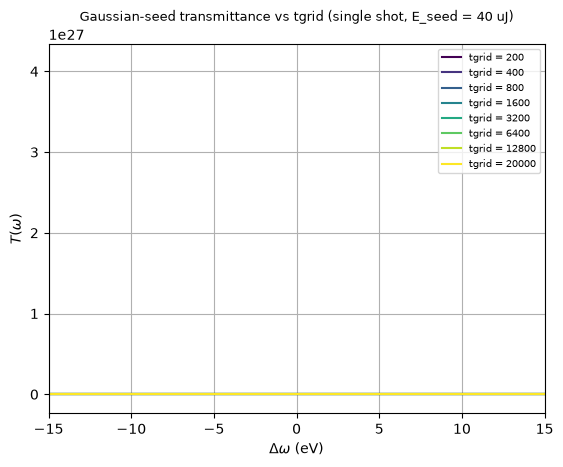

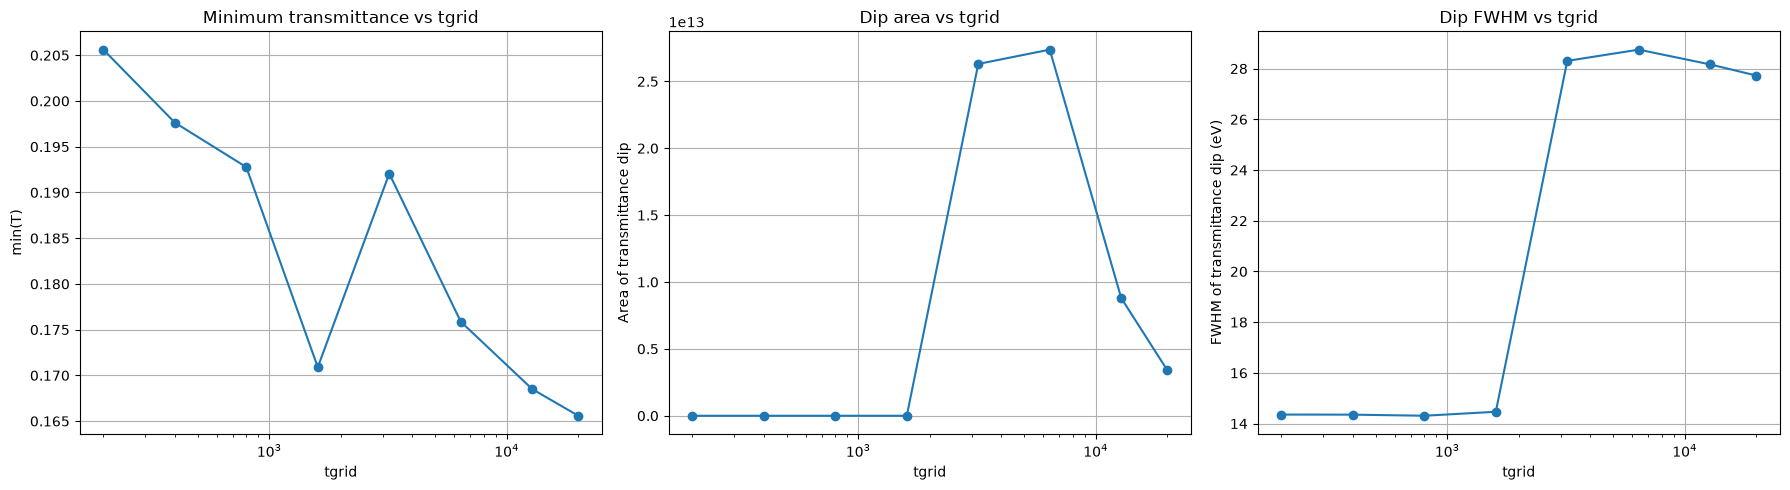

In [20]:
results_tgrid = run_grid_sweep('tgrid', TGRID_VALUES, FIXED_TGRID, FIXED_XYGRID, FIXED_ZGRID)
_ = plot_grid_sweep(results_tgrid, grid_label='tgrid')


### xgrid/ygrid (transverse grid) convergence

running xgrid=2  (tgrid=800, xgrid=ygrid=2, zgrid=15)
norm =  0.0005600625694663986
number of seed photons = 3.1e+10
running xgrid=4  (tgrid=800, xgrid=ygrid=4, zgrid=15)
norm =  0.7960950199518791
number of seed photons = 3.1e+10
running xgrid=8  (tgrid=800, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running xgrid=16  (tgrid=800, xgrid=ygrid=16, zgrid=15)
norm =  0.9999630397497831
number of seed photons = 3.1e+10
running xgrid=32  (tgrid=800, xgrid=ygrid=32, zgrid=15)
norm =  0.9999294816618309
number of seed photons = 3.1e+10


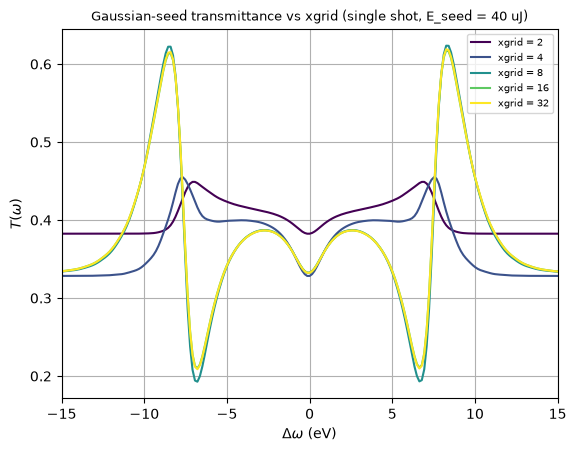

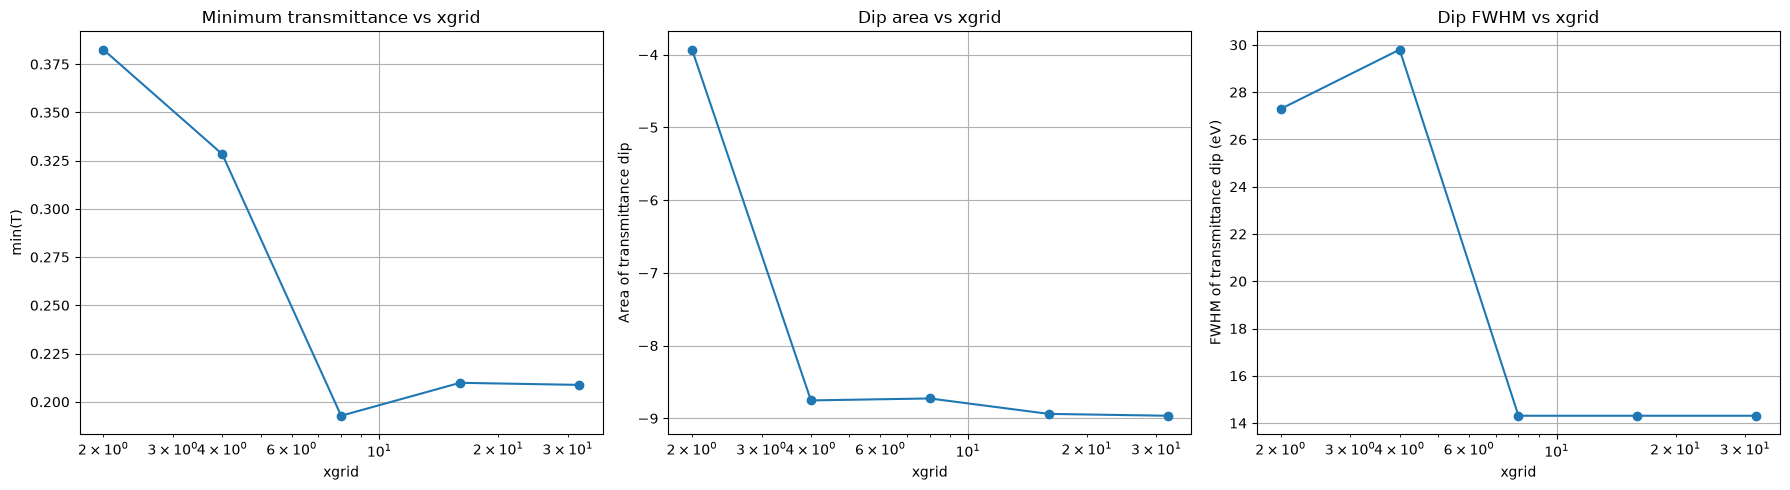

In [18]:
results_xygrid = run_grid_sweep('xgrid', XYGRID_VALUES, FIXED_TGRID, FIXED_XYGRID, FIXED_ZGRID)
_ = plot_grid_sweep(results_xygrid, grid_label='xgrid')


### zgrid convergence

running zgrid=5  (tgrid=800, xgrid=ygrid=8, zgrid=5)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running zgrid=10  (tgrid=800, xgrid=ygrid=8, zgrid=10)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running zgrid=15  (tgrid=800, xgrid=ygrid=8, zgrid=15)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running zgrid=20  (tgrid=800, xgrid=ygrid=8, zgrid=20)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running zgrid=30  (tgrid=800, xgrid=ygrid=8, zgrid=30)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running zgrid=40  (tgrid=800, xgrid=ygrid=8, zgrid=40)
norm =  0.9999508435362797
number of seed photons = 3.1e+10
running zgrid=50  (tgrid=800, xgrid=ygrid=8, zgrid=50)
norm =  0.9999508435362797
number of seed photons = 3.1e+10


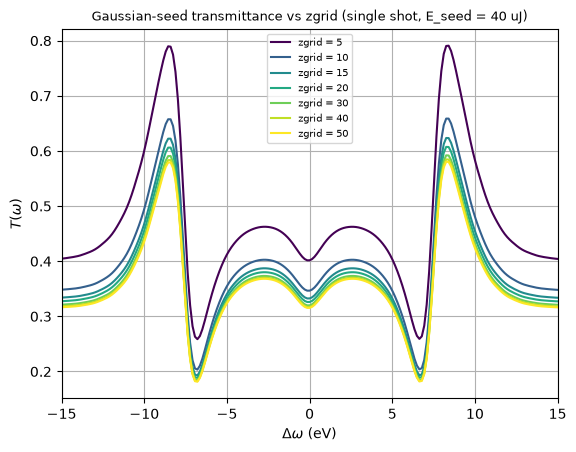

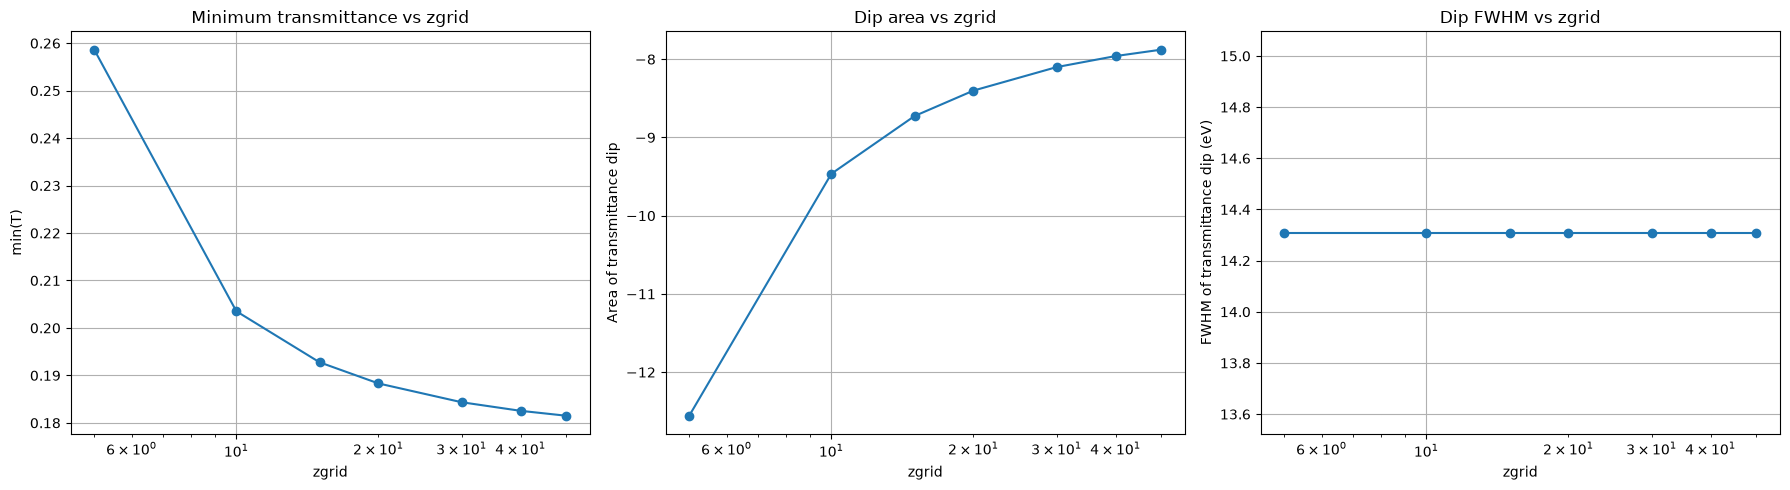

In [19]:
results_zgrid = run_grid_sweep('zgrid', ZGRID_VALUES, FIXED_TGRID, FIXED_XYGRID, FIXED_ZGRID)
_ = plot_grid_sweep(results_zgrid, grid_label='zgrid')
